In [21]:
# Supervise Learning 
## 1. Import Necessary Libraries
## 2. Load and Explore the dataset
## 3. Splitting Data into Training and Test Sets
## 4. Data Preprocessing
## 5. Model Fitting, Test, Evaluation  
## 6. Evaluation models

In [22]:
# Unsupervised Learning Steps for Hierarchical Clustering:
# Step 1: Import libraries.
# Step 2: Load, explore, and visualize the data.
# Step 3: Drop irrelevant features and handle noise.
# Step 4: Normalize the data for clustering.
# Step 5: Apply PCA or other techniques for dimensionality reduction.
# Step 6: Use a dendrogram to find the optimal number of clusters.
# Step 7: Apply Hierarchical Clustering with the selected clusters.
# Step 8: Assign cluster labels to data points.
# Step 9: Evaluate clustering with metrics like Silhouette Score.
# Step 10: Visualize clusters and centroids.
# Step 11: Analyze clusters to understand characteristics and patterns.
# Step 12: Refine clustering by experimenting with linkage methods or algorithms.

Hierarchical Clustering is a clustering algorithm that builds a hierarchy of clusters through either an agglomerative (bottom-up) or divisive (top-down) approach.

Agglomerative (Bottom-Up): This method starts by treating each data point as its own cluster. It then iteratively merges the closest clusters based on a distance metric until all points are grouped into a single cluster.

Divisive (Top-Down): This method starts with all data points in a single cluster and progressively splits the clusters into smaller sub-clusters based on some criteria.

Linkage Methods:

Single Linkage: The minimum distance between points in two clusters is used to determine their proximity.

Complete Linkage: The maximum distance between points in two clusters is used to determine their proximity.

Average Linkage: The average distance between all points in the two clusters is used to determine their proximity.

Ward Method: This method minimizes the variance within clusters, ensuring that the resulting clusters are as compact and homogeneous as possible.

Key Points:

Hierarchical clustering does not require the number of clusters to be specified in advance, as the algorithm produces a hierarchy of clusters from which the number of clusters can be determined later.

The output of hierarchical clustering is typically visualized in the form of a dendrogram, a tree-like diagram that illustrates the merging or splitting of clusters at various levels.

The optimal number of clusters can be determined by cutting the dendrogram at a specific level, where the desired number of clusters is obtained.

Agglomerative hierarchical clustering begins with individual data points as clusters and merges them based on proximity, while divisive clustering starts with all data points in a single cluster and splits them iteratively.

## 1. Import Necessary Libraries

In [23]:

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from ydata_profiling import ProfileReport

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler, OneHotEncoder
from sklearn.metrics import silhouette_score
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA

from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from scipy.cluster.hierarchy import dendrogram, linkage

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)


## 2. Load, Explore and Initial Visualization data

In [24]:
df = pd.read_csv("C:\\Users\\Dell\\Desktop\\AAA 2024\\2024 Python Data Science\\Machine Learning\\earthquake_data.csv")

In [25]:
print(df.head())
print(df.info())

                                          title  magnitude         date_time  \
0  M 7.0 - 18 km SW of Malango, Solomon Islands        7.0  22-11-2022 02:03   
1      M 6.9 - 204 km SW of Bengkulu, Indonesia        6.9  18-11-2022 13:37   
2                                      M 7.0 -         7.0  12-11-2022 07:09   
3           M 7.3 - 205 km ESE of Neiafu, Tonga        7.3  11-11-2022 10:48   
4                                      M 6.6 -         6.6  09-11-2022 10:14   

   cdi  mmi  alert  tsunami  sig net  nst   dmin   gap magType    depth  \
0    8    7  green        1  768  us  117  0.509  17.0     mww   14.000   
1    4    4  green        0  735  us   99  2.229  34.0     mww   25.000   
2    3    3  green        1  755  us  147  3.125  18.0     mww  579.000   
3    5    5  green        1  833  us  149  1.865  21.0     mww   37.000   
4    0    2  green        1  670  us  131  4.998  27.0     mww  624.464   

   latitude  longitude                  location continent          

title          0
magnitude      0
date_time      0
cdi            0
mmi            0
alert        367
tsunami        0
sig            0
net            0
nst            0
dmin           0
gap            0
magType        0
depth          0
latitude       0
longitude      0
location       5
continent    576
country      298
dtype: int64


<Axes: >

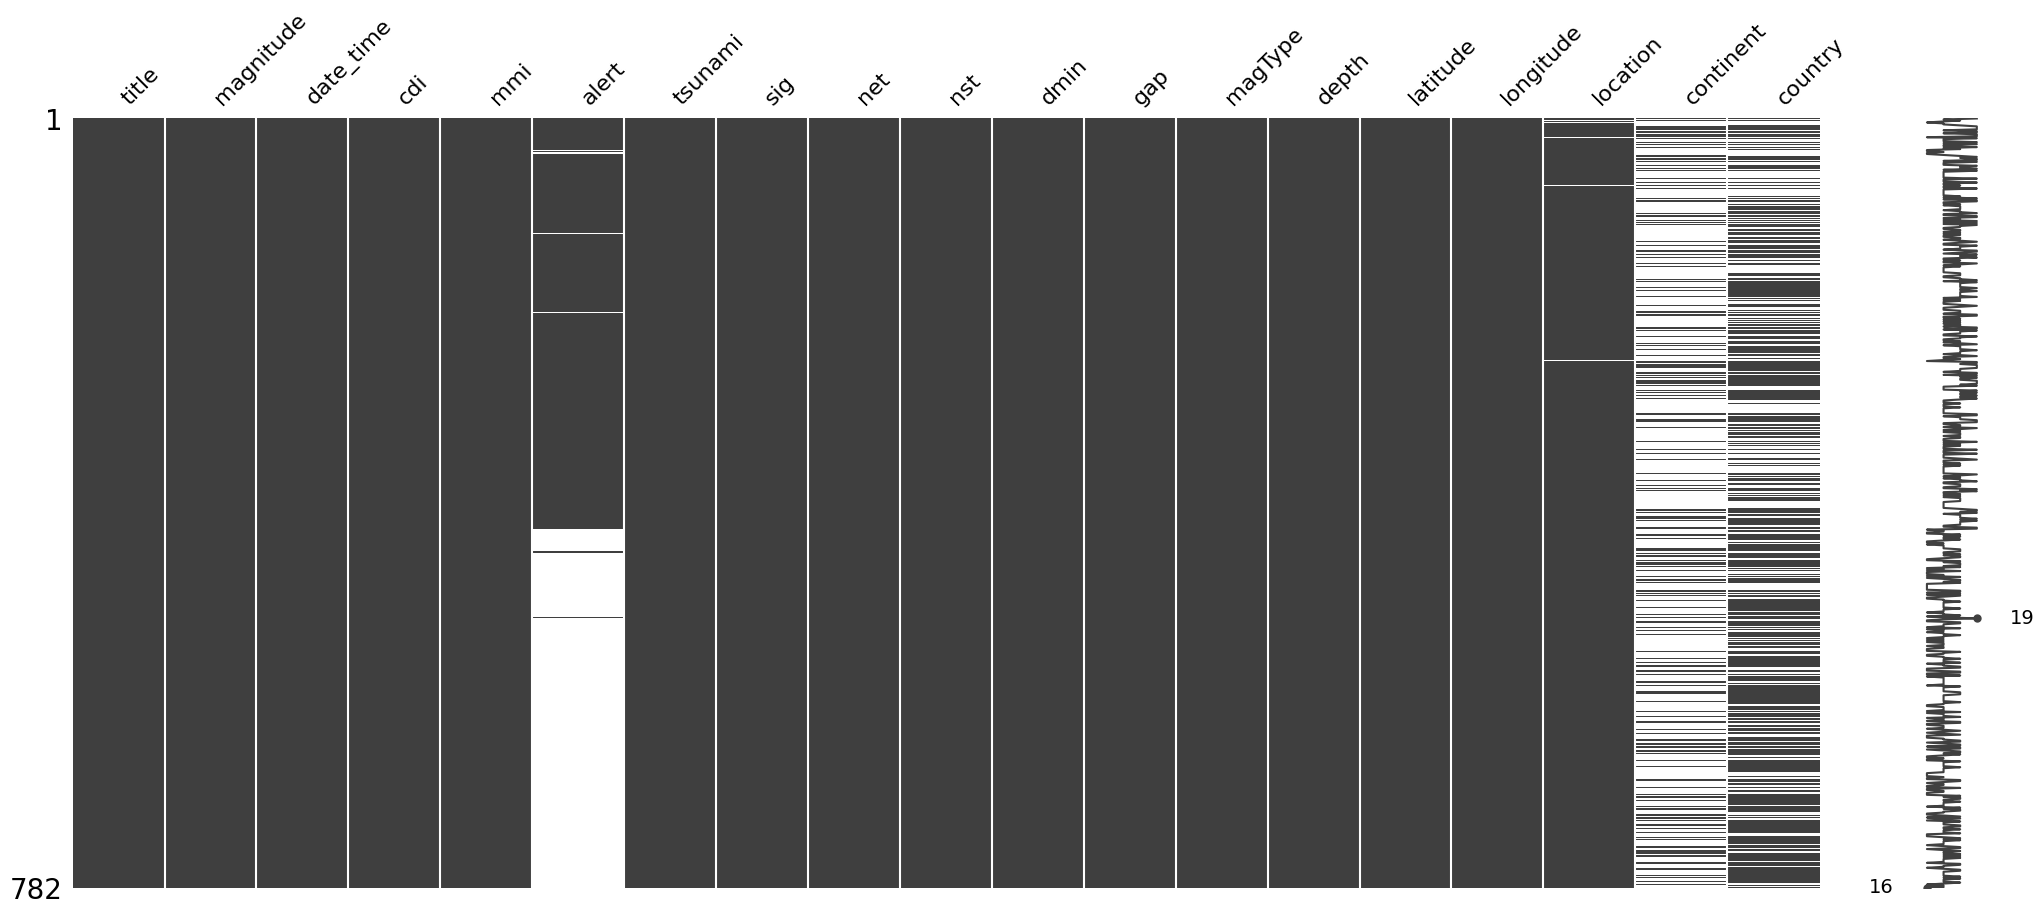

In [26]:
missing_counts = df.isnull().sum()
print(missing_counts)
msno.matrix(df)

In [27]:
print(df.duplicated().sum())

0


In [28]:
print((df == 0).sum())

title          0
magnitude      0
date_time      0
cdi          212
mmi            0
alert          0
tsunami      478
sig            0
net            0
nst          365
dmin         405
gap           70
magType        0
depth          0
latitude       0
longitude      0
location       0
continent      0
country        0
dtype: int64


In [29]:
print("Columns with exactly 2 unique values:")
for col in df.columns:
    unique_values = df[col].dropna().unique()  
    if len(unique_values) == 2:
        print(f"Column '{col}':")
        print(df[col].value_counts())

Columns with exactly 2 unique values:
Column 'tsunami':
tsunami
0    478
1    304
Name: count, dtype: int64


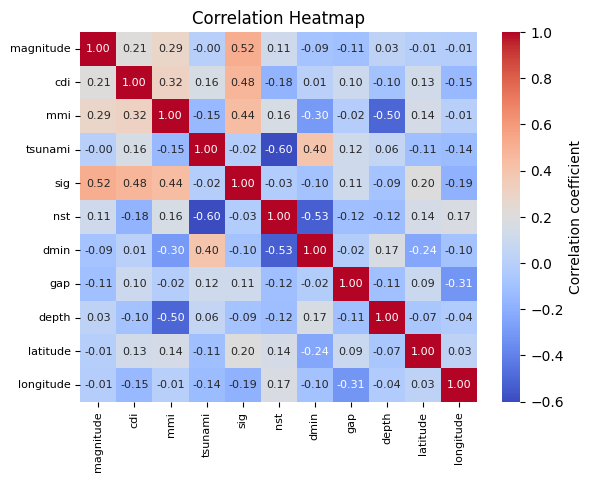

In [30]:
numeric_data = df.select_dtypes(include=['float64', 'int64'])

sns.heatmap(numeric_data.corr(), annot=True, 
             cmap="coolwarm", fmt=".2f", annot_kws={"size": 8}, 
             cbar_kws={'label': 'Correlation coefficient'})
plt.title("Correlation Heatmap")
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
plt.show()

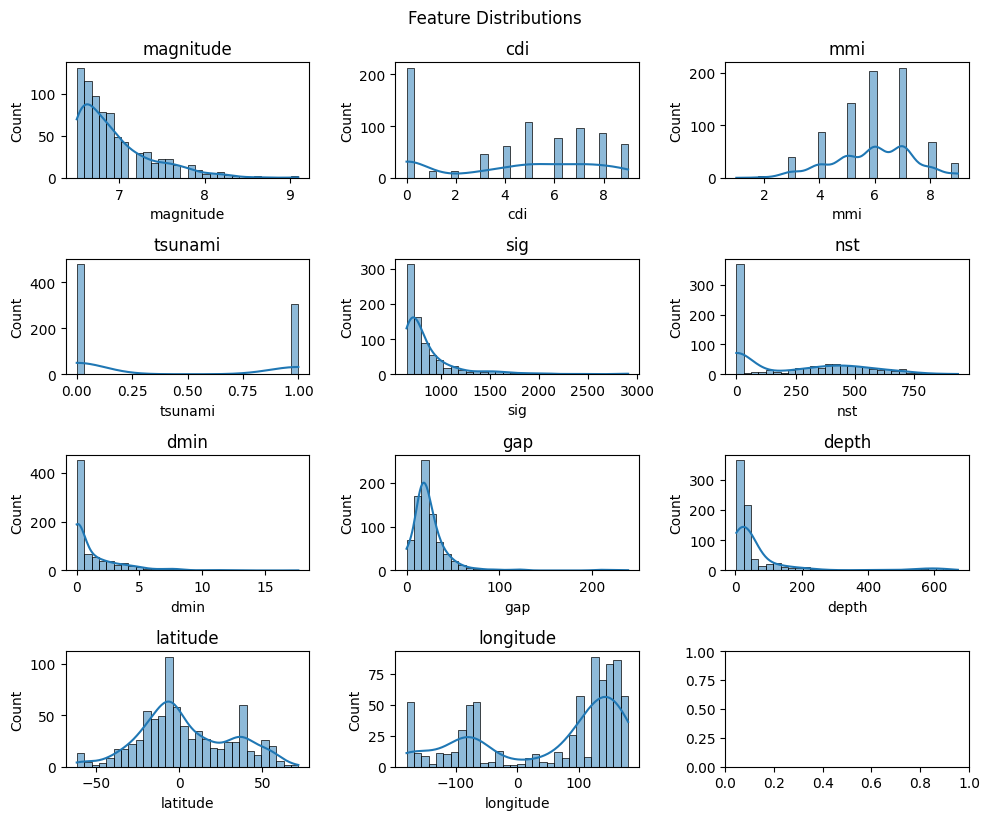

In [31]:
# Feature Distributions:
numeric_columns = df.select_dtypes(include=['number']).columns
fig, axes = plt.subplots(4, 3, figsize=(10, 8))
axes = axes.flatten()
for i, column in enumerate(numeric_columns):
    sns.histplot(data=df, x=column, kde=True, bins=30, ax=axes[i])  
    axes[i].set_title(f'{column}')  
plt.tight_layout()
plt.suptitle("Feature Distributions", y=1.02)  
plt.show()

In [33]:
# Skewness and kurtosis help evaluate the distribution of numerical features
# Skewness close to 0 suggests a symmetric distribution, 
# positive skew (>0) indicates a right tail,  
# negative skew (<0) indicates a left tail.

# Kurtosis values around 3 indicate a normal distribution. 
# Values > 3 suggest heavy tails (outliers), 
# while < 3 suggests light tails.

print("Skewness for numerical columns:")
print(df.select_dtypes(include=['number']).skew())

print("Kurtosis for numerical columns:")
print(df.select_dtypes(include=['number']).kurt())

Skewness for numerical columns:
magnitude    1.444440
cdi         -0.197310
mmi         -0.250403
tsunami      0.457333
sig          3.083629
nst          0.533307
dmin         2.604580
gap          4.668607
depth        3.024869
latitude     0.200853
longitude   -0.702982
dtype: float64
Kurtosis for numerical columns:
magnitude     2.226391
cdi          -1.357753
mmi          -0.224592
tsunami      -1.795445
sig          12.000754
nst          -1.092793
dmin          9.283367
gap          32.027722
depth         8.384480
latitude     -0.476740
longitude    -1.088383
dtype: float64


Number of outliers in each column: 
magnitude     37
cdi            0
mmi            1
tsunami        0
sig           73
nst            0
dmin          61
gap           48
depth        139
latitude       0
longitude      0
dtype: int64


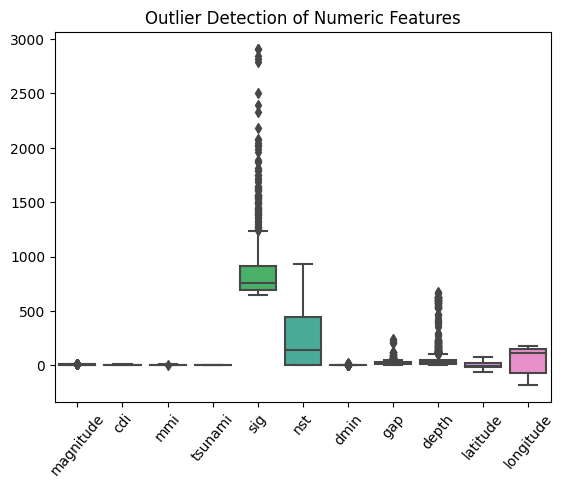

In [34]:
# Outlier Detection 
numeric_df = df.select_dtypes(include=['float64', 'int64'])
Q1 = numeric_df.quantile(0.25)
Q3 = numeric_df.quantile(0.75)
IQR = Q3 - Q1
outliers = ((numeric_df < (Q1 - 1.5 * IQR)) | (numeric_df > (Q3 + 1.5 * IQR))).sum()
print(f"Number of outliers in each column: \n{outliers}")

sns.boxplot(data=numeric_df)
plt.title("Outlier Detection of Numeric Features")
plt.xticks(rotation=50)
plt.show()

In [35]:
df['date_time'] = pd.to_datetime(df['date_time'], format='%d-%m-%Y %H:%M')
print(df['date_time'].head())

0   2022-11-22 02:03:00
1   2022-11-18 13:37:00
2   2022-11-12 07:09:00
3   2022-11-11 10:48:00
4   2022-11-09 10:14:00
Name: date_time, dtype: datetime64[ns]


In [36]:
# removing spaces, converting to lowercase for object columns
object_columns = df.select_dtypes(include=['object']).columns
for column in object_columns:
    df[column] = df[column].str.strip().str.replace(' ', '').str.lower()
print(df.head())

                                 title  magnitude           date_time  cdi  \
0  m7.0-18kmswofmalango,solomonislands        7.0 2022-11-22 02:03:00    8   
1     m6.9-204kmswofbengkulu,indonesia        6.9 2022-11-18 13:37:00    4   
2                                m7.0-        7.0 2022-11-12 07:09:00    3   
3          m7.3-205kmeseofneiafu,tonga        7.3 2022-11-11 10:48:00    5   
4                                m6.6-        6.6 2022-11-09 10:14:00    0   

   mmi  alert  tsunami  sig net  nst   dmin   gap magType    depth  latitude  \
0    7  green        1  768  us  117  0.509  17.0     mww   14.000   -9.7963   
1    4  green        0  735  us   99  2.229  34.0     mww   25.000   -4.9559   
2    3  green        1  755  us  147  3.125  18.0     mww  579.000  -20.0508   
3    5  green        1  833  us  149  1.865  21.0     mww   37.000  -19.2918   
4    2  green        1  670  us  131  4.998  27.0     mww  624.464  -25.5948   

   longitude                location continent    

In [16]:
# Group columns by their data types
for dtype in df.dtypes.unique():
    print(f"\n{dtype} columns:")
    print(df.select_dtypes(include=[dtype]).columns.tolist())


object columns:
['title', 'date_time', 'alert', 'net', 'magType', 'location', 'continent', 'country']

float64 columns:
['magnitude', 'dmin', 'gap', 'depth', 'latitude', 'longitude']

int64 columns:
['cdi', 'mmi', 'tsunami', 'sig', 'nst']


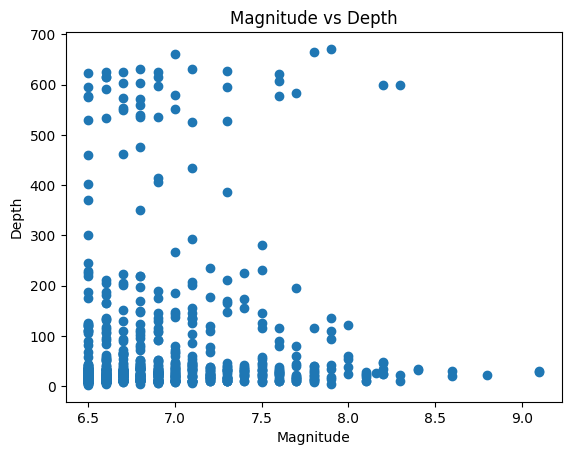

In [37]:
# Visualizing some numerical features 
plt.scatter(df['magnitude'], df['depth'])
plt.xlabel('Magnitude')
plt.ylabel('Depth')
plt.title('Magnitude vs Depth')
plt.show()


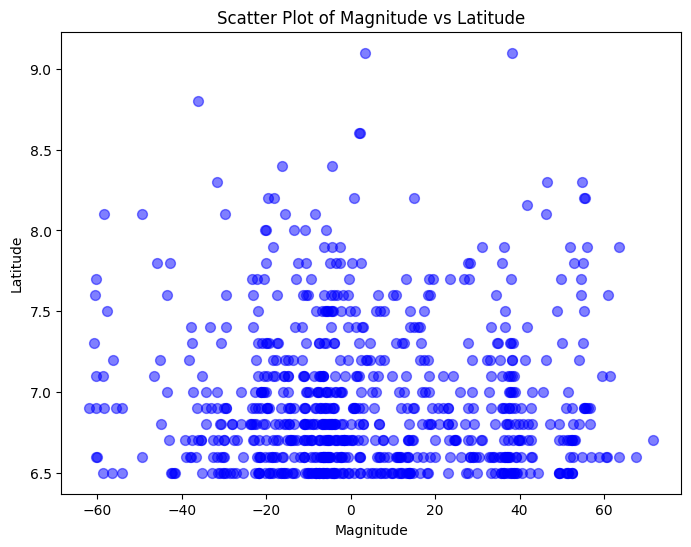

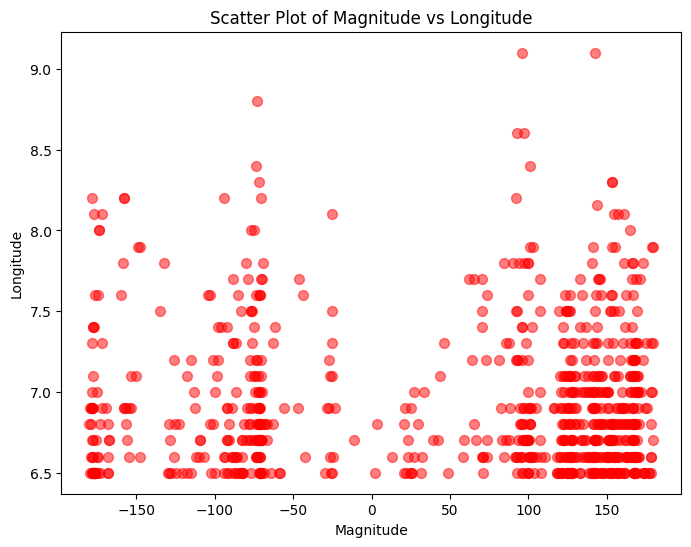

In [38]:
# Scatter plot of Magnitude vs Latitude
plt.figure(figsize=(8, 6))
plt.scatter(df['latitude'], df['magnitude'], s=50, color='blue', alpha=0.5)
plt.ylabel('Latitude')
plt.xlabel('Magnitude')
plt.title('Scatter Plot of Magnitude vs Latitude')
plt.show()

# Scatter plot of Magnitude vs Longitude
plt.figure(figsize=(8, 6))
plt.scatter(df['longitude'], df['magnitude'], s=50, color='red', alpha=0.5)
plt.ylabel('Longitude')
plt.xlabel('Magnitude')
plt.title('Scatter Plot of Magnitude vs Longitude')
plt.show()


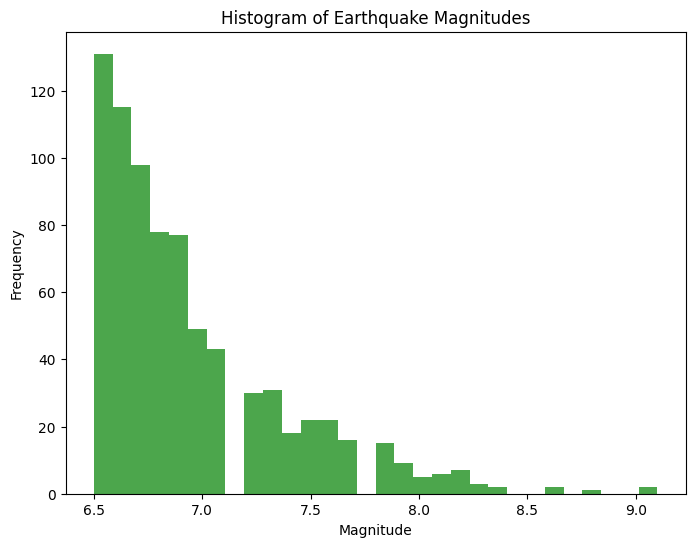

In [39]:
# Histogram of earthquake magnitudes
plt.figure(figsize=(8, 6))
plt.hist(df['magnitude'], bins=30, color='green', alpha=0.7)
plt.xlabel('Magnitude')
plt.ylabel('Frequency')
plt.title('Histogram of Earthquake Magnitudes')
plt.show()


## 3. Drop Feature not relevant 

In [40]:
drop_columns = ['title', 'location', 'net', 'date_time', 'country']
data = df.drop(columns=drop_columns)  
print(f"data: {data.shape}")
print(data.dtypes)

data: (782, 14)
magnitude    float64
cdi            int64
mmi            int64
alert         object
tsunami        int64
sig            int64
nst            int64
dmin         float64
gap          float64
magType       object
depth        float64
latitude     float64
longitude    float64
continent     object
dtype: object


## 4. Data Preprocessing

In [41]:
numerical_columns = data.select_dtypes(include=['float64', 'int64']).columns.tolist()
numerical_imputer = SimpleImputer(strategy='median')
data[numerical_columns] = numerical_imputer.fit_transform(data[numerical_columns])
print(f"Preprocessed Data:\n{data.head()}")

Preprocessed Data:
   magnitude  cdi  mmi  alert  tsunami    sig    nst   dmin   gap magType  \
0        7.0  8.0  7.0  green      1.0  768.0  117.0  0.509  17.0     mww   
1        6.9  4.0  4.0  green      0.0  735.0   99.0  2.229  34.0     mww   
2        7.0  3.0  3.0  green      1.0  755.0  147.0  3.125  18.0     mww   
3        7.3  5.0  5.0  green      1.0  833.0  149.0  1.865  21.0     mww   
4        6.6  0.0  2.0  green      1.0  670.0  131.0  4.998  27.0     mww   

     depth  latitude  longitude continent  
0   14.000   -9.7963    159.596   oceania  
1   25.000   -4.9559    100.738       NaN  
2  579.000  -20.0508   -178.346   oceania  
3   37.000  -19.2918   -172.129       NaN  
4  624.464  -25.5948    178.278       NaN  


In [42]:
def cap_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[column] = df[column].clip(lower=lower_bound, upper=upper_bound)
numerical_columns = data.select_dtypes(include=['float64', 'int64']).columns
for col in numerical_columns:
    cap_outliers(data, col)
print(f"Preprocessed Data:\n{data.head()}")

Preprocessed Data:
   magnitude  cdi  mmi  alert  tsunami    sig    nst    dmin   gap magType  \
0        7.0  8.0  7.0  green      1.0  768.0  117.0  0.5090  17.0     mww   
1        6.9  4.0  4.0  green      0.0  735.0   99.0  2.2290  34.0     mww   
2        7.0  3.0  3.0  green      1.0  755.0  147.0  3.1250  18.0     mww   
3        7.3  5.0  5.0  green      1.0  833.0  149.0  1.8650  21.0     mww   
4        6.6  0.0  2.0  green      1.0  670.0  131.0  4.6575  27.0     mww   

     depth  latitude  longitude continent  
0   14.000   -9.7963    159.596   oceania  
1   25.000   -4.9559    100.738       NaN  
2  103.375  -20.0508   -178.346   oceania  
3   37.000  -19.2918   -172.129       NaN  
4  103.375  -25.5948    178.278       NaN  


In [43]:
scaler_robust = RobustScaler()
numerical_columns = data.select_dtypes(include=['float64', 'int64']).columns
data[numerical_columns] = scaler_robust.fit_transform(data[numerical_columns])
print(f"Preprocessed Data:\n{data.head()}")

Preprocessed Data:
   magnitude       cdi  mmi  alert  tsunami       sig       nst      dmin  \
0        0.4  0.428571  0.5  green      1.0  0.064000 -0.051685  0.273215   
1        0.2 -0.142857 -1.0  green      0.0 -0.086857 -0.092135  1.196457   
2        0.4 -0.285714 -1.5  green      1.0  0.004571  0.015730  1.677402   
3        1.0  0.000000 -0.5  green      1.0  0.361143  0.020225  1.001074   
4       -0.4 -0.714286 -2.0  green      1.0 -0.384000 -0.020225  2.500000   

        gap magType     depth  latitude  longitude continent  
0 -0.195122     mww -0.343916 -0.184045   0.227416   oceania  
1  0.910569     mww -0.036224 -0.060723  -0.039382       NaN  
2 -0.130081     mww  2.156084 -0.445306  -1.304443   oceania  
3  0.065041     mww  0.299441 -0.425968  -1.276262       NaN  
4  0.455285     mww  2.156084 -0.586554   0.312100       NaN  


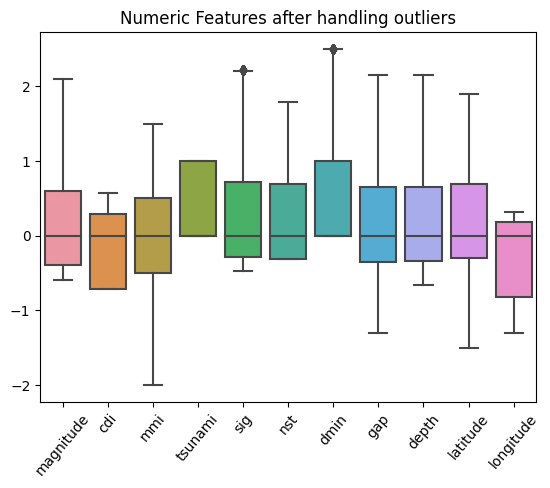

In [44]:
sns.boxplot(data=data[numerical_columns])
plt.title("Numeric Features after handling outliers")
plt.xticks(rotation=50)
plt.show()

In [45]:
object_columns = data.select_dtypes(include=['object']).columns.tolist()
object_imputer = SimpleImputer(strategy='most_frequent')
data[object_columns] = object_imputer.fit_transform(data[object_columns])
print(data[object_columns].isnull().sum())
print(f"Preprocessed Data set:\n{data.head()}")

alert        0
magType      0
continent    0
dtype: int64
Preprocessed Data set:
   magnitude       cdi  mmi  alert  tsunami       sig       nst      dmin  \
0        0.4  0.428571  0.5  green      1.0  0.064000 -0.051685  0.273215   
1        0.2 -0.142857 -1.0  green      0.0 -0.086857 -0.092135  1.196457   
2        0.4 -0.285714 -1.5  green      1.0  0.004571  0.015730  1.677402   
3        1.0  0.000000 -0.5  green      1.0  0.361143  0.020225  1.001074   
4       -0.4 -0.714286 -2.0  green      1.0 -0.384000 -0.020225  2.500000   

        gap magType     depth  latitude  longitude continent  
0 -0.195122     mww -0.343916 -0.184045   0.227416   oceania  
1  0.910569     mww -0.036224 -0.060723  -0.039382      asia  
2 -0.130081     mww  2.156084 -0.445306  -1.304443   oceania  
3  0.065041     mww  0.299441 -0.425968  -1.276262      asia  
4  0.455285     mww  2.156084 -0.586554   0.312100      asia  


In [46]:
Onehot_encoder_columns = ['alert', 'magType', 'continent']
Onehot_encoder = OneHotEncoder(sparse_output=False)
for col in Onehot_encoder_columns:
    transformed_train = Onehot_encoder.fit_transform(data[[col]])
    column_names = [f"{col}_{category}" for category in Onehot_encoder.categories_[0]]
    data = pd.concat([data, pd.DataFrame(transformed_train, columns=column_names, index=data.index)], axis=1)
    data.drop(columns=[col], inplace=True)
print(f"Preprocessed Data:\n{data.head()}")

Preprocessed Data:
   magnitude       cdi  mmi  tsunami       sig       nst      dmin       gap  \
0        0.4  0.428571  0.5      1.0  0.064000 -0.051685  0.273215 -0.195122   
1        0.2 -0.142857 -1.0      0.0 -0.086857 -0.092135  1.196457  0.910569   
2        0.4 -0.285714 -1.5      1.0  0.004571  0.015730  1.677402 -0.130081   
3        1.0  0.000000 -0.5      1.0  0.361143  0.020225  1.001074  0.065041   
4       -0.4 -0.714286 -2.0      1.0 -0.384000 -0.020225  2.500000  0.455285   

      depth  latitude  ...  magType_mw  magType_mwb  magType_mwc  magType_mww  \
0 -0.343916 -0.184045  ...         0.0          0.0          0.0          1.0   
1 -0.036224 -0.060723  ...         0.0          0.0          0.0          1.0   
2  2.156084 -0.445306  ...         0.0          0.0          0.0          1.0   
3  0.299441 -0.425968  ...         0.0          0.0          0.0          1.0   
4  2.156084 -0.586554  ...         0.0          0.0          0.0          1.0   

   continent_

# Step 5: Dimensionality Reduction

In [47]:
# PCA applied to reduce data to 2 dimensions
pca = PCA(n_components=2)
data_pca = pca.fit_transform(data)

# Step 6: Use the Dendrogram to find the optimal number of clusters.

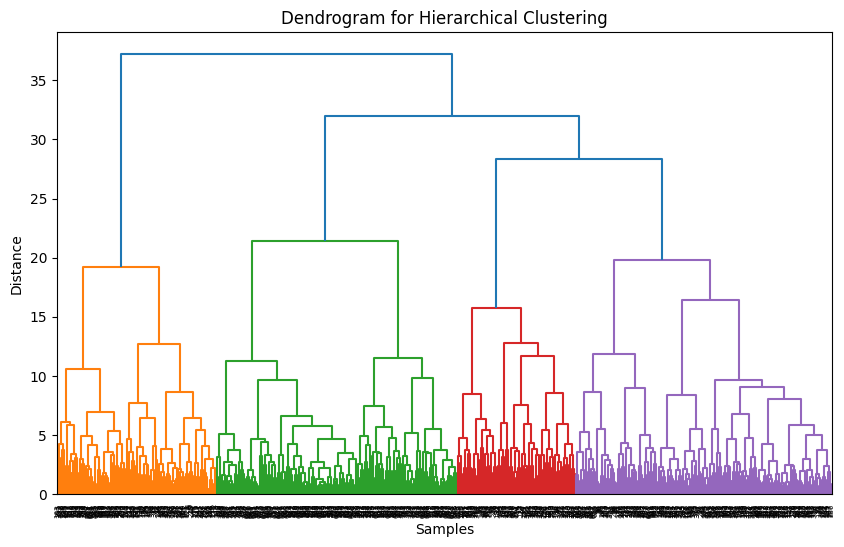

In [48]:
# Generate the linkage matrix ['ward', 'complete', 'average', 'single']
Z = linkage(data, method='ward')
plt.figure(figsize=(10, 6))
dendrogram(Z)
plt.title('Dendrogram for Hierarchical Clustering')
plt.xlabel('Samples')
plt.ylabel('Distance')
plt.show()

# 7.  Choose the optimal number and Apply Agglomerative Clustering 8. Assign Clusters to Data Points 9. Evaluate the Clustering

In [49]:
# Choose the optimal number of clusters (based on the dendrogram)
# Choose the optimal number of clusters ['ward', 'complete', 'average', 'single']
n_clusters = 2
# Apply Agglomerative Clustering
agg_clust = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
df['cluster'] = agg_clust.fit_predict(data)

silhouette = silhouette_score(data, df['cluster'])
print(f"Silhouette Score: {silhouette:.5f}")

Silhouette Score: 0.17175


# 10. Visualize the Results

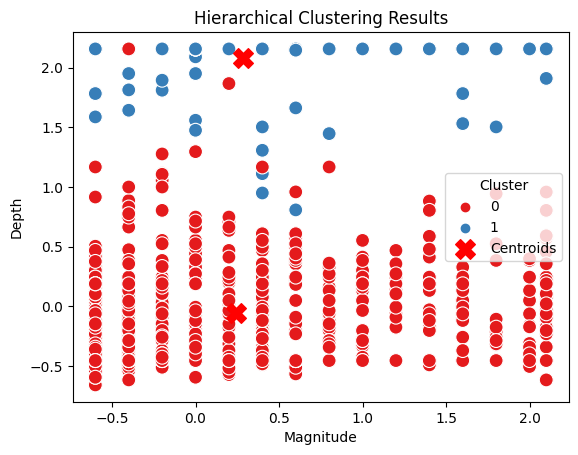

In [50]:
sns.scatterplot(x=data['magnitude'], y=data['depth'], hue=df['cluster'], palette='Set1', s=100)
plt.xlabel('Magnitude')
plt.ylabel('Depth')
plt.title('Hierarchical Clustering Results')

centroids = data.groupby(df['cluster'])[['magnitude', 'depth']].mean()
plt.scatter(centroids['magnitude'], centroids['depth'], c='red', marker='X', s=200, label='Centroids')
plt.legend(title='Cluster')
plt.show()

# 11. Interpret Results

The Silhouette Score is a metric used to evaluate the quality of clusters in a dataset. It measures how similar each data point is to its own cluster compared to other clusters. 

The score ranges from -1 to +1:

A score of +1 indicates that the point is well-clustered, meaning it is far from other clusters.

A score of 0 suggests that the point is on or near the boundary between two clusters.

A score of -1 indicates that the point is poorly clustered, meaning it may be assigned to the wrong cluster.

In this case, the Silhouette Score of 0.17175 is relatively low, suggesting that the clustering results are not well-separated. 

The data points within the clusters are somewhat close to points in other clusters, which indicates that the chosen number of clusters (2 in this case) may not be optimal. 

This low score implies that the current clustering configuration may not effectively capture the underlying structure of the data. 

Further optimization, such as adjusting the number of clusters or exploring different clustering algorithms, may be necessary to achieve better results.

# 12. Iterate and Improve

In [51]:
# Choose the optimal number of clusters ['ward', 'complete', 'average', 'single']
n_clusters = 2
agg_clust = AgglomerativeClustering(n_clusters=n_clusters, linkage='single')
df['cluster'] = agg_clust.fit_predict(data)
silhouette = silhouette_score(data, df['cluster'])
print(f"Silhouette Score: {silhouette:.5f}")

Silhouette Score: 0.22781
